In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generate Fake Uber Data for 500 rides
np.random.seed(42)
distance_km = np.random.uniform(1, 20, 500)
# Price is roughly 15 rupees per km, plus a base fare of 40, plus some random traffic noise
actual_price = (distance_km * 15) + 40 + np.random.normal(0, 20, 500)

uber_data = pd.DataFrame({
    'Distance_KM': distance_km,
    'Price_INR': actual_price
})

print("Here is our Uber Database:")
print(uber_data.head())

Here is our Uber Database:
   Distance_KM   Price_INR
0     8.116262  168.579053
1    19.063572  363.476994
2    14.907885  282.626750
3    12.374511  214.079595
4     3.964354   81.497019


The AI predicts a 10km ride will cost: ₹190.04


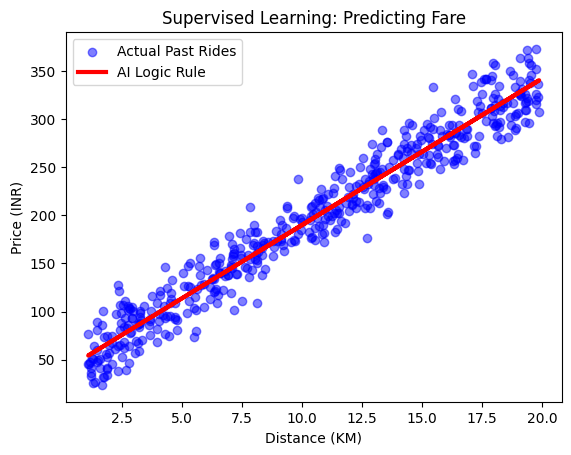

In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Split data into X (Input/Distance) and y (Output/Price)
X = uber_data[['Distance_KM']]
y = uber_data['Price_INR']

# 2. Build and train the Supervised AI
price_model = LinearRegression()
price_model.fit(X, y)

# 3. Test it on a brand new 10km ride
new_ride = pd.DataFrame({'Distance_KM': [10]})
predicted_fare = price_model.predict(new_ride)

print(f"The AI predicts a 10km ride will cost: ₹{predicted_fare[0]:.2f}")

# VISUALIZE IT
plt.scatter(X, y, color='blue', alpha=0.5, label='Actual Past Rides')
plt.plot(X, price_model.predict(X), color='red', linewidth=3, label='AI Logic Rule')
plt.title("Supervised Learning: Predicting Fare")
plt.xlabel("Distance (KM)")
plt.ylabel("Price (INR)")
plt.legend()
plt.show()

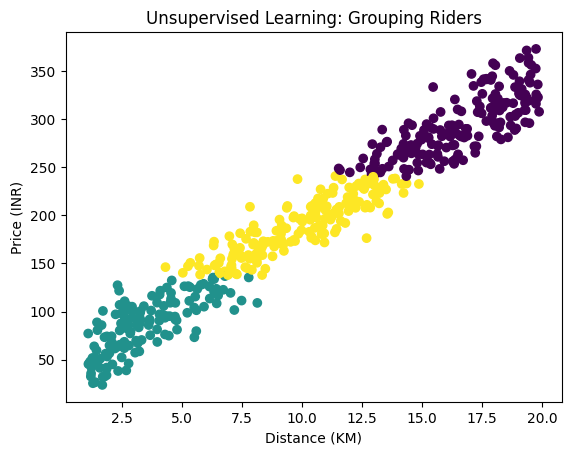

In [ ]:
from sklearn.cluster import KMeans

# 1. We just give it the raw data, no labels
data_for_clustering = uber_data[['Distance_KM', 'Price_INR']]

# 2. Tell the AI to find 3 distinct groups (clusters) of riders
# n_clusters is a HYPERPARAMETER
clustering_model = KMeans(n_clusters=3, random_state=42, n_init=10)
uber_data['Rider_Type'] = clustering_model.fit_predict(data_for_clustering)

# VISUALIZE IT
plt.scatter(uber_data['Distance_KM'], uber_data['Price_INR'], c=uber_data['Rider_Type'], cmap='viridis')
plt.title("Unsupervised Learning: Grouping Riders")
plt.xlabel("Distance (KM)")
plt.ylabel("Price (INR)")
plt.show()

In [ ]:
import random

# The 3 actions the AI can take
surge_options = [1.0, 1.5, 2.0]
# The AI's memory of how much money each action makes
ai_memory_rewards = [0, 0, 0]
times_tried = [0, 0, 0]

print("AI is learning the best surge price by trial and error...\n")

for ride in range(100):
    # AI randomly picks a surge price to test (Exploration)
    action_index = random.randint(0, 2)
    chosen_surge = surge_options[action_index]

    # Environment Logic (The Real World Reaction)
    if chosen_surge == 1.0:
        reward = 50 # Riders always accept, but profit is low
    elif chosen_surge == 1.5:
        reward = 75 if random.random() > 0.2 else 0 # 20% of riders cancel
    elif chosen_surge == 2.0:
        reward = 100 if random.random() > 0.6 else 0 # 60% of riders cancel angry

    # AI updates its memory based on the reward it got
    ai_memory_rewards[action_index] += reward
    times_tried[action_index] += 1

# Calculate average reward per surge level
average_rewards = [ai_memory_rewards[i] / (times_tried[i] + 1) for i in range(3)]

for i in range(3):
    print(f"Surge {surge_options[i]}x earned an average of ₹{average_rewards[i]:.2f} per ride.")

best_action = surge_options[np.argmax(average_rewards)]
print(f"\nReinforcement Learning complete. AI sets final surge to: {best_action}x")

AI is learning the best surge price by trial and error...

Surge 1.0x earned an average of ₹47.83 per ride.
Surge 1.5x earned an average of ₹64.02 per ride.
Surge 2.0x earned an average of ₹33.33 per ride.

Reinforcement Learning complete. AI sets final surge to: 1.5x
